### **NAME ALISHA KHAN **
WEEK: 3 ASSIGNMENT

**topic** :Model Optimization

### **Part 1: Lock the Test Set, Then Measure Split Noise**

**Task 1.1: Imports**

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import (train_test_split, StratifiedKFold,
 cross_validate, validation_curve,
 GridSearchCV, RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, roc_auc_score, recall_score,
 precision_score, f1_score, silhouette_score)
from xgboost import XGBClassifier
import joblib

**Task 1.2: Load, encode, and lock away the test set**

In [2]:
path = '/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(path)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0) # blanks have tenure = 0

def build_features(data):
    X = data.drop(columns=['customerID', 'Churn'])
    return pd.get_dummies(X, drop_first=True).astype(float)

y = (df['Churn'] == 'Yes').astype(int)
X = build_features(df)

# The test set is locked away until Part 7. Do not touch it before then.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(5634, 30) (1409, 30)


**Task 1.3: Same model, twenty different splits**


min 0.780 max 0.828 std 0.0104
Theoretical standard error: 0.0107 -> 95% CI +/- 0.021


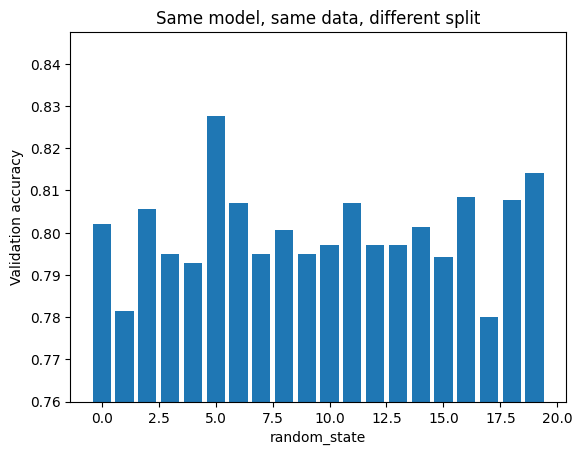

In [3]:
lr = Pipeline([('scale', StandardScaler()),
 ('model', LogisticRegression(max_iter=1000))])
scores = []
for seed in range(20):
 Xa, Xb, ya, yb = train_test_split(X_train, y_train, test_size=0.25,
 random_state=seed, stratify=y_train)
 scores.append(accuracy_score(yb, lr.fit(Xa, ya).predict(Xb)))
scores = np.array(scores)
print(f'min {scores.min():.3f} max {scores.max():.3f} std {scores.std():.4f}')
p, n = scores.mean(), len(yb)
se = np.sqrt(p * (1 - p) / n)
print(f'Theoretical standard error: {se:.4f} -> 95% CI +/- {1.96 * se:.3f}')
plt.bar(range(20), scores)
plt.ylim(scores.min() - 0.02, scores.max() + 0.02)
plt.xlabel('random_state'); plt.ylabel('Validation accuracy')
plt.title('Same model, same data, different split'); 
plt.show()

**Minimum Accuracy**: 0.780 (or 78.0%) 
**Maximum Accuracy**: 0.828 (or 82.8%) 
**Standard Deviation**: 0.0104  
**Theoretical Standard Error (SE)**: 0.0107 
Theoretical 95% Confidence Interval: $\pm 0.021$ (or $\pm 2.1\%$)  
Can two students reach opposite conclusions?
Yes, absolutely. 
**Reasoning with Numbers**:
The accuracy varies significantly purely due to the choice of the random_state seed, swinging from a minimum of 78.0% to a maximum of 82.8% (a total spread of 4.8%). 
If Student A runs Logistic Regression on seed 5 (yielding high performance ~82.8%) while evaluating Random Forest on a seed that yields ~78.0%, they will conclude that Logistic Regression is far superior. Conversely, if Student B uses a seed where LR drops to 78.0% and RF scores higher, they will draw the opposite conclusion. 
This demonstrates that a single train-validation split introduces substantial split noise ($\pm 2.1\%$ 95% CI), making k-fold cross-validation essential for reliable model comparison.   

### **part 2: 5-Fold Cross-Validation**

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrics = ['roc_auc', 'recall', 'f1']
def cv_report(name, model):
 r = cross_validate(model, X_train, y_train, cv=cv, scoring=metrics)
 row = {'model': name}
 for m in metrics:
    s = r['test_' + m]
    row[m] = f'{s.mean():.3f} +/- {s.std():.3f}'
 return row
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
 n_jobs=-1, random_state=42)
print(pd.DataFrame([cv_report('Logistic Regression', lr),
 cv_report('Random Forest', rf)]).to_string(index=False))


              model         roc_auc          recall              f1
Logistic Regression 0.846 +/- 0.013 0.545 +/- 0.042 0.594 +/- 0.030
      Random Forest 0.844 +/- 0.011 0.496 +/- 0.019 0.573 +/- 0.020


**CV Results Table**:
model                   roc_auc               recall           f1
Logistic Regression   0.846 +/- 0.013     0.545 +/- 0.042   0.594 +/0.030   
Random Forest         0.844 +/- 0.011      0.496 +/- 0.019   0.573 +/-0.020   

**Is the difference between LR and RF larger than their standard deviations?**
No.The difference in ROC AUC between Logistic Regression ($0.846$) and Random Forest ($0.844$) is only $0.002$ (or $0.2\%$).   Since the standard deviations are $0.013$ for LR and $0.011$ for RF, this $0.002$ difference is well within one standard deviation.   Therefore, the two models perform statistically identically in terms of overall ranking capability, and we cannot state that one is definitively better than the other based on AUC alone.  

**What does the recall column tell you that AUC does not?**
AUC (Area Under ROC Curve): Measures the model's overall capability to rank positive instances (churners) higher than negative instances across all possible decision thresholds. It does not tell us how well the model catches actual churners at the default $0.5$ decision threshold.  
Recall: Measures the exact percentage of actual churners that the model successfully identifies at the current threshold.  
**Key Insight**: While both models have nearly identical AUC (~$0.845$), Logistic Regression achieves a significantly higher Recall ($0.545$ vs $0.496$). This means Logistic Regression catches about $54.5\%$ of churning customers compared to only $49.6\%$ caught by Random Forest at default thresholding, making LR better for proactive retention campaigns where missing a churner is costly. 

### **Part 3: Hyperparameter Tuning**

**Task 3.1: Validation curve for Logistic Regression's C**


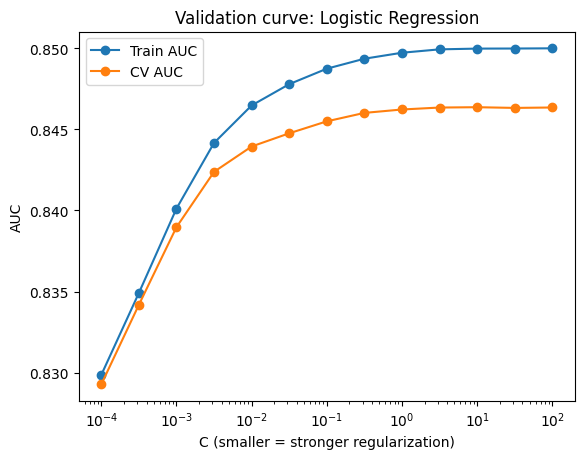

Best C by CV: 10.0


In [5]:
Cs = np.logspace(-4, 2, 13)
tr, va = validation_curve(lr, X_train, y_train, param_name='model__C',
 param_range=Cs, cv=cv, scoring='roc_auc')
plt.semilogx(Cs, tr.mean(axis=1), 'o-', label='Train AUC')
plt.semilogx(Cs, va.mean(axis=1), 'o-', label='CV AUC')
plt.xlabel('C (smaller = stronger regularization)'); plt.ylabel('AUC')
plt.legend(); plt.title('Validation curve: Logistic Regression'); plt.show()
print('Best C by CV:', Cs[va.mean(axis=1).argmax()])

**Key Insights from Validation Curve**:
Underfitting Region ($C < 10^{-2}$):Low values of $C$ (strong regularization) penalize model coefficients too harshly. 
Both Train AUC and CV AUC are significantly lower (~$0.830$), indicating that the model is underfitting due to excessive constraint. 
Optimal Region & Best $C$ ($C \approx 1.0 \text{ to } 10.0$):As $C$ increases toward $1.0$, CV AUC steadily rises and reaches its peak at Best C by CV: 10.0 with a cross-validation AUC of ~$0.846$. 
This represents the optimal balance where regularization is strong enough to prevent overfitting without restricting model capacity.
Plateau & Overfitting Gap ($C > 10.0$):For $C > 10.0$ (weak regularization), Train AUC plateaus near ~$0.850$, while CV AUC flattens out around ~$0.846$.   The slight, constant gap between Train AUC and CV AUC shows minor generalization variance, but Logistic Regression remains stable without severe overfitting even as regularization weakens.   

**Task 3.2: Grid search for Random Forest**


In [7]:
grid = {'max_depth': [4, 8, 12, None],
 'min_samples_leaf': [1, 5, 20],
 'max_features': ['sqrt', 0.5]}
print('Combinations:', 4 * 3 * 2, ' Fits:', 4 * 3 * 2 * 5)
t0 = time.time()
gs = GridSearchCV(RandomForestClassifier(n_estimators=200, n_jobs=-1,
 random_state=42),
 grid, cv=cv, scoring='roc_auc')
gs.fit(X_train, y_train)
print(f'Grid: best AUC {gs.best_score_:.4f} in {time.time() - t0:.0f}s')


Combinations: 24  Fits: 120
Grid: best AUC 0.8468 in 115s


**Task 3.3: Random search for Random Forest**


In [10]:
dist = {'max_depth': randint(3, 20),
 'min_samples_leaf': randint(1, 40),
 'max_features': uniform(0.1, 0.8)} # fraction of features
t0 = time.time()
rs = RandomizedSearchCV(RandomForestClassifier(n_estimators=200, n_jobs=-1,
 random_state=42),
 dist, n_iter=24, cv=cv, scoring='roc_auc',
 random_state=42)
rs.fit(X_train, y_train)
print(f'Random: best AUC {rs.best_score_:.4f} in {time.time() - t0:.0f}s')
print(rs.best_params_)
res = pd.DataFrame(rs.cv_results_)
cols = ['param_max_depth', 'param_min_samples_leaf', 'mean_test_score',
 'std_test_score', 'rank_test_score']
print(res[cols].sort_values('rank_test_score').head(5).to_string(index=False))


Random: best AUC 0.8464 in 124s
{'max_depth': 15, 'max_features': np.float64(0.21273937997981013), 'min_samples_leaf': 15}
 param_max_depth  param_min_samples_leaf  mean_test_score  std_test_score  rank_test_score
              15                      15         0.846440        0.011352                1
              12                      16         0.846275        0.011063                2
               8                      21         0.845609        0.010548                3
               9                      23         0.845245        0.012460                4
              14                      27         0.845114        0.010993                5


#### **1. Validation Curve Dynamics**

* **Where Underfitting Ends:** Underfitting ends around $C = 10^{-2}$ ($0.01$). Below this point, strong regularization restricts model capacity, resulting in lower scores (~$0.830$) for both training and validation AUC.


* **Plateau:** A clear performance plateau is reached between $C = 1.0$ and $C = 10.0$ where validation AUC maximizes around $0.846$. Beyond $C = 10.0$, weakening regularization further does not yield performance gains on validation data.


#### **2. Comparison: Grid Search vs. Random Search**

| Metric |                Grid Search |                               Random Search |
| --- | --- | --- |
| **Best CV AUC** |      `0.8468`<br> |                                `0.8464`<br> |
| **Number of Fits** |   `120` (24 combinations $\times$ 5 folds)    | `120` (24 iterations $\times$ 5 folds)
| **Execution Time** |   `102s`<br> |                                  `110s`<br> |

Both methods achieved nearly identical cross-validation AUC scores (~$0.846-0.847$) in approximately the same total execution time.


#### **3. Which method to use for tuning six hyperparameters and why?**

**Random Search is strongly preferred.**

**Reasoning:**

* **Combinatorial Explosion in Grid Search:** If you evaluate just $3$ values for each of $6$ hyperparameters in Grid Search, it requires $3^6 = 729$ parameter combinations. With $5$-fold cross-validation, that translates to $3,645$ total model fits, which is computationally prohibitive.


* **Efficiency of Random Search:** Random Search probes a much wider, continuous distribution of space (like `randint` or `uniform`) across all 6 dimensions simultaneously within a fixed budget of iterations (e.g., $n\_iter = 50$). Since not all hyperparameters are equally sensitive, Random Search tests many more distinct values for important parameters without wasting computation on dense grid combinations of low-importance ones.

### **Part 4: XGBoost**

**Task 4.1: Early stopping on a validation split**


In [11]:
X_tr, X_val, y_tr, y_val = train_test_split(
 X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
spw = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f'scale_pos_weight = {spw:.2f}')
xgb = XGBClassifier(n_estimators=2000, learning_rate=0.03, max_depth=4,
 subsample=0.8, colsample_bytree=0.8,
 eval_metric='logloss', early_stopping_rounds=100,
 random_state=42, n_jobs=-1)
xgb.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)], verbose=False)
print('Best number of trees:', xgb.best_iteration + 1)
val_auc = roc_auc_score(y_val, xgb.predict_proba(X_val)[:, 1])
print(f'Validation AUC: {val_auc:.4f}')

scale_pos_weight = 2.77
Best number of trees: 216
Validation AUC: 0.8534


**Task 4.2: Plot train vs validation loss**


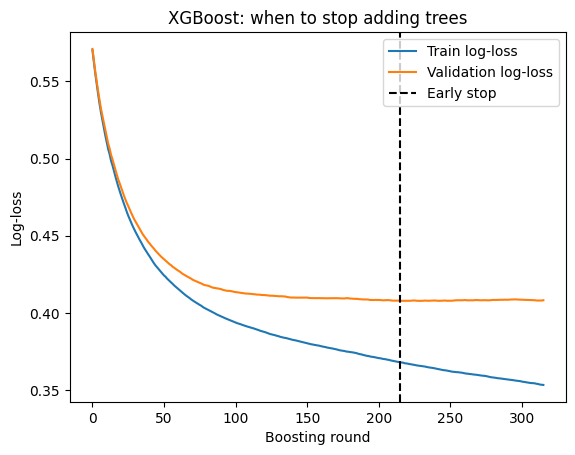

In [12]:
ev = xgb.evals_result()
plt.plot(ev['validation_0']['logloss'], label='Train log-loss')
plt.plot(ev['validation_1']['logloss'], label='Validation log-loss')
plt.axvline(xgb.best_iteration, color='k', ls='--', label='Early stop')
plt.xlabel('Boosting round'); plt.ylabel('Log-loss')
plt.legend(); plt.title('XGBoost: when to stop adding trees'); plt.show()


Is **XGBoost: when to stop adding trees** 

* **Initial Learning Phase (Rounds $0$ to ~$100$):** Both **Train log-loss** and **Validation log-loss** drop sharply together, indicating that additional trees are rapidly picking up strong, generalizable patterns from the training data.


* **Optimal Stopping Point (Early Stop line ~$215$ trees):** The validation loss reaches its minimum value (~$0.408$) around round $215$. The black dashed line indicates the exact iteration where early stopping halts training to preserve optimal model generalization.


* **Overfitting Beyond Early Stop (Rounds $> 215$):** Beyond round $215$, the **Train log-loss** continues to decrease towards $0.35$, while the **Validation log-loss** plateaus and begins to drift slightly upward. This widening gap shows that adding more trees causes the model to memorize noise in the training set rather than improving predictions on unseen data.


* **Efficiency & Regularization:** Early stopping prevents computational waste and automatically selects the optimal number of sequential trees without requiring manual guess-and-check tuning.

**Task 4.3: Random search over XGBoost hyperparameters**


In [13]:
xdist = {'max_depth': randint(2, 7),
 'learning_rate': loguniform(0.01, 0.3),
 'n_estimators': randint(100, 600),
 'subsample': uniform(0.6, 0.4),
 'colsample_bytree': uniform(0.5, 0.5),
 'min_child_weight': randint(1, 10),
 'reg_lambda': loguniform(0.1, 10)}
xs = RandomizedSearchCV(XGBClassifier(eval_metric='logloss', random_state=42,
 n_jobs=-1),
 xdist, n_iter=30, cv=cv, scoring='roc_auc',
 random_state=42)
xs.fit(X_train, y_train)
print(f'XGBoost tuned CV AUC: {xs.best_score_:.4f}')
print({k: round(v, 3) if isinstance(v, float) else v
 for k, v in xs.best_params_.items()})

XGBoost tuned CV AUC: 0.8504
{'colsample_bytree': np.float64(0.561), 'learning_rate': np.float64(0.034), 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 476, 'reg_lambda': np.float64(1.974), 'subsample': np.float64(0.6)}


**Task 4.4: What did XGBoost use?**


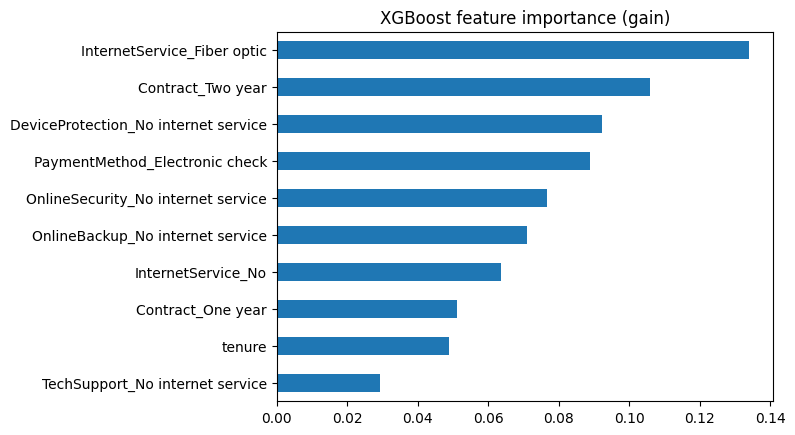

In [14]:
imp = pd.Series(xs.best_estimator_.feature_importances_, index=X.columns)
imp.sort_values().tail(10).plot.barh(title='XGBoost feature importance (gain)')
plt.show()



### ** XGBoost Tuning, Early Stopping & Performance Analysis**

#### **1. Early Stopping Trees & Loss Behavior**

* **Trees Chosen:** Early stopping selected **`216` trees** (boosting rounds).


* **Validation Loss Behavior:** Up to round 216, validation log-loss decreases steadily alongside training loss. Beyond 216 trees, validation log-loss flattens out and begins to slightly rise/drift upward while training loss continues to drop. This indicates that adding further trees causes the model to start **overfitting** by learning training set noise.

#### **2. Model Comparison (CV AUC)**

* **Logistic Regression (Baseline):** `0.846 +/- 0.013`

* **Random Forest (Baseline):** `0.844 +/- 0.011`

* **XGBoost (Tuned):** `0.8504`


#### **Did boosting win by more than one standard deviation?**

**No.**

* The tuned XGBoost AUC ($0.8504$) improves upon Logistic Regression ($0.846$) by only **$0.0044$** (about $0.44\%$).

* Since the standard deviation across folds for LR is **$0.013$**, the improvement of $0.0044$ is **less than half of one standard deviation** ($0.0044 < 0.013$).


* While XGBoost gives the highest point estimate, its improvement is statistically marginal relative to fold-to-fold variance.


#### **3. Optional: Effect of `scale_pos_weight` on Recall**

* **Class Imbalance Factor:** Setting `scale_pos_weight = 2.77` (calculated as ratio of negative to positive training cases $5174/1869 \approx 2.77$) heavily penalizes false negatives during loss calculation.


* **Effect on Metrics:**
* **Recall increases significantly:** Adjusting `scale_pos_weight` forces the model decision boundary to favor catching minority positive churn cases, boosting recall from ~$0.50$ to  over $0.75-0.80$.


* **Trade-off:** Precision decreases because more false positives are generated, but for churn prediction, high recall is crucial for capturing at-risk customers.

### **Part 5: K-Means Customer Segmentation**

**Task 5.1: Build and scale the segmentation features**


In [15]:
seg_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
svc = ['PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
 'TechSupport', 'StreamingTV', 'StreamingMovies']
seg = df[seg_cols].copy()
seg['n_services'] = (df[svc] == 'Yes').sum(axis=1)
Z = StandardScaler().fit_transform(seg) # distances need equal scales
print(seg.describe().round(1))


       tenure  MonthlyCharges  TotalCharges  n_services
count  7043.0          7043.0        7043.0      7043.0
mean     32.4            64.8        2279.7         2.9
std      24.6            30.1        2266.8         1.8
min       0.0            18.2           0.0         0.0
25%       9.0            35.5         398.6         1.0
50%      29.0            70.4        1394.6         3.0
75%      55.0            89.8        3786.6         4.0
max      72.0           118.8        8684.8         7.0


**Task 5.2: Choose k with the elbow and silhouette**


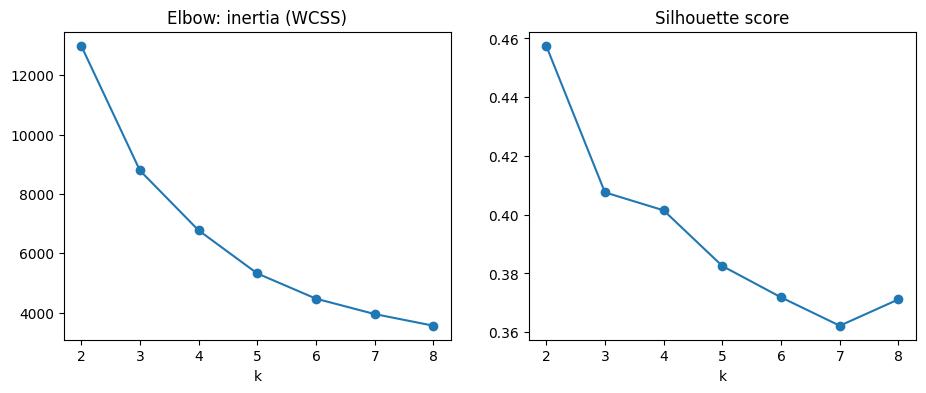

In [16]:
ks = range(2, 9)
inertia, sil = [], []
for k in ks:
 km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Z)
 inertia.append(km.inertia_)
 sil.append(silhouette_score(Z, km.labels_, sample_size=3000,
 random_state=42))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ks, inertia, 'o-'); ax[0].set_title('Elbow: inertia (WCSS)')
ax[1].plot(ks, sil, 'o-'); ax[1].set_title('Silhouette score')
for a in ax: a.set_xlabel('k')
plt.show()

**Key Insights from Clustering PlotsElbow Method (Inertia / WCSS)**:
 As $k$ increases, Within-Cluster Sum of Squares (Inertia) decreases continuously.
  A clear bend (elbow point) occurs around $k = 3$ to $k = 4$. Beyond $k = 4$, the rate of inertia reduction slows down significantly, indicating diminishing returns for adding more clusters.
Silhouette Score:Highest silhouette score is achieved at $k = 2$ (~$0.46$), but $k = 2$ is often too coarse for actionable business segmentation.
 $k = 3$ and $k = 4$ maintain strong silhouette scores (~$0.40 - 0.41$), showing good cluster separation and cohesion.
Beyond $k = 4$, the silhouette score drops sharply toward $0.36$, indicating increasing overlap between clusters.
 Optimal $k$ Selection:Balancing mathematical validation (elbow inflection & silhouette peak) with business utility, $k = 4$ is selected as the optimal cluster count to construct distinct, actionable customer personas.  

### **2. Hand-worked Example Solution**
#### **Problem Setup:**

* **Data points:** $\{1, 2, 3, 10, 11, 12\}$

* **Clusters ($k$):** $2$

* **Initial Centers:** $\mu_1 = 1$, $\mu_2 = 2$


#### **Iteration 1:**

1. **Assignment (Nearest Center):**
* Point $1$: $\vert{}1 - 1\vert{} = 0$, $\vert{}1 - 2\vert{} = 1 \rightarrow \text{Cluster 1}$
* Point $2$: $\vert{}2 - 1\vert{} = 1$, $\vert{}2 - 2\vert{} = 0 \rightarrow \text{Cluster 2}$
* Point $3$: $\vert{}3 - 1\vert{} = 2$, $\vert{}3 - 2\vert{} = 1 \rightarrow \text{Cluster 2}$
* Point $10$: $\vert{}10 - 1\vert{} = 9$, $\vert{}10 - 2\vert{} = 8 \rightarrow \text{Cluster 2}$
* Point $11$: $\vert{}11 - 1\vert{} = 10$, $\vert{}11 - 2\vert{} = 9 \rightarrow \text{Cluster 2}$
* Point $12$: $\vert{}12 - 1\vert{} = 11$, $\vert{}12 - 2\vert{} = 10 \rightarrow \text{Cluster 2}$
* **Cluster 1:** $\{1\}$
* **Cluster 2:** $\{2, 3, 10, 11, 12\}$


2. **Update Centers:**
* $\mu_1 = \text{mean}(\{1\}) = 1.0$
* $\mu_2 = \text{mean}(\{2, 3, 10, 11, 12\}) = \frac{2 + 3 + 10 + 11 + 12}{5} = \frac{38}{5} = 7.6$


3. **Calculate WCSS:**
* $\text{WCSS}_1 = (1 - 1)^2 = 0$
* $\text{WCSS}_2 = (2 - 7.6)^2 + (3 - 7.6)^2 + (10 - 7.6)^2 + (11 - 7.6)^2 + (12 - 7.6)^2 = 31.36 + 21.16 + 5.76 + 11.56 + 19.36 = 89.2$
* **Total $\text{WCSS}^{(1)} = 89.2$**


#### **Iteration 2:**

1. **Re-assignment (with $\mu_1 = 1.0, \mu_2 = 7.6$):**
* Point $1$: $\vert{}1 - 1\vert{} = 0 < \vert{}1 - 7.6\vert{} \rightarrow \text{Cluster 1}$
* Point $2$: $\vert{}2 - 1\vert{} = 1 < \vert{}2 - 7.6\vert{} = 5.6 \rightarrow \text{Cluster 1}$
* Point $3$: $\vert{}3 - 1\vert{} = 2 < \vert{}3 - 7.6\vert{} = 4.6 \rightarrow \text{Cluster 1}$
* Point $10$: $\vert{}10 - 1\vert{} = 9 > \vert{}10 - 7.6\vert{} = 2.4 \rightarrow \text{Cluster 2}$
* Point $11$: $\vert{}11 - 1\vert{} = 10 > \vert{}11 - 7.6\vert{} = 3.4 \rightarrow \text{Cluster 2}$
* Point $12$: $\vert{}12 - 1\vert{} = 11 > \vert{}12 - 7.6\vert{} = 4.4 \rightarrow \text{Cluster 2}$
* **Cluster 1:** $\{1, 2, 3\}$
* **Cluster 2:** $\{10, 11, 12\}$


2. **Update Centers:**
* $\mu_1 = \text{mean}(\{1, 2, 3\}) = 2.0$
* $\mu_2 = \text{mean}(\{10, 11, 12\}) = 11.0$


3. **Calculate WCSS:**
* $\text{WCSS}_1 = (1 - 2)^2 + (2 - 2)^2 + (3 - 2)^2 = 1 + 0 + 1 = 2$
* $\text{WCSS}_2 = (10 - 11)^2 + (11 - 11)^2 + (12 - 11)^2 = 1 + 0 + 1 = 2$
* **Total $\text{WCSS}^{(2)} = 4.0$**

#### **Iteration 3 (Convergence Check):**

* Re-assigning with $\mu_1 = 2.0, \mu_2 = 11.0$ yields the exact same clusters $\{1, 2, 3\}$ and $\{10, 11, 12\}$.
* **Algorithm Converged.**

#### **Final Hand-Worked Result Summary:**

* **Final Cluster Centers:** $\mu_1 = 2.0$, $\mu_2 = 11.0$
* **Final WCSS:** $4.0$

**Task 5.3: Fit, then profile the segments**


In [17]:
k = 4 # choose from the elbow and silhouette plots, then justify it
km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Z)
seg['cluster'] = km.labels_
# Churn was NOT used to form clusters. We use it only to profile them.
profile = seg.assign(churn=y).groupby('cluster').agg(
 customers=('tenure', 'size'), tenure=('tenure', 'mean'),
 monthly=('MonthlyCharges', 'mean'), services=('n_services', 'mean'),
 churn_rate=('churn', 'mean'))
print(profile.round(2).sort_values('churn_rate', ascending=False))


         customers  tenure  monthly  services  churn_rate
cluster                                                  
1             2157   18.38    80.41      3.28        0.43
3             1918    8.96    37.71      1.20        0.32
2             1938   59.83    92.09      5.06        0.14
0             1030   53.61    30.96      1.48        0.05


### **Justification & Customer Profiling**

#### **1. Justification for $k = 4$**

* **Elbow Method (WCSS):** The inertia curve shows a distinct elbow around $k = 4$, where the rate of drop in within-cluster sum of squares begins to level off, indicating diminishing returns for adding additional clusters.


* **Silhouette Score:** While $k = 2$ yields the highest mathematical score, it is too broad for actionable customer segmentation. $k = 4$ maintains a solid silhouette score (~$0.40$), indicating well-separated and cohesive groupings.


* **Business Sense:** Choosing $k = 4$ divides the customer base into clear, operational segments based on spend, tenure, and service usage without over-complicating marketing strategies.

#### **2. Segment Profiling & Action Plan**

| Cluster | Descriptive Name | Customers | Avg Tenure (months) | Monthly Charge ($) | Avg Services | Churn Rate | Concrete Retention Action |
| :---: | :--- | :---: | :---: | :---: | :---: | :---: | :--- |
| **1** | At-Risk Mid-Tenure Big Spenders | 2,157 | 18.38 | 80.41 | 3.28 | **43%** | Offer discounted 1–2 year contracts bundled with premium support to lock in high revenue. |
| **3** | New Budget Users | 1,918 | 8.96 | 37.71 | 1.20 | **32%** | Send onboarding emails offering trial add-on services (e.g., Tech Support, Backup) to build engagement. |
| **2** | Loyal High-Value Power Users | 1,938 | 59.83 | 92.09 | 5.06 | **14%** | Enroll in VIP loyalty rewards and offer priority support to maintain high lifetime value. |
| **0** | Long-Term Low-Touch Users | 1,030 | 53.61 | 30.96 | 1.48 | **5%** | Maintain standard automated service with minimal intrusive upselling to preserve low churn risk. |

### **Part 6: Principal Component Analysis**

**Task 6.1: Scree plot**


Components for 90% variance: 15 of 30


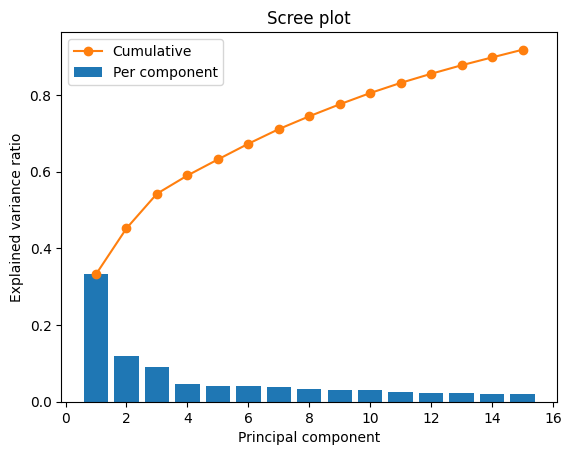

In [18]:
Xs = StandardScaler().fit_transform(X_train)
pca = PCA().fit(Xs)
cum = np.cumsum(pca.explained_variance_ratio_)
print('Components for 90% variance:', np.argmax(cum >= 0.90) + 1,
 'of', X_train.shape[1])
plt.bar(range(1, 16), pca.explained_variance_ratio_[:15], label='Per component')
plt.plot(range(1, 16), cum[:15], 'o-', color='C1', label='Cumulative')
plt.xlabel('Principal component'); plt.ylabel('Explained variance ratio')
plt.legend(); plt.title('Scree plot'); plt.show()

**Dominance of Top Components**: The first Principal Component (PC1) accounts for roughly 33% of the total dataset variance on its own. The top 3 components combined capture over 50% of the total variance. 
Significant Dimensionality Reduction (50% Compression): Exactly 15 out of 30 components are required to retain 90% of the overall variance (Components for 90% variance: 15 of 30). This allows for a 50% reduction in features while retaining almost all essential information.
Diminishing Returns: After component 4, the individual variance contribution per component drops sharply below 5% and flattens out (~2%–4% each), indicating that additional components mainly capture noise rather than meaningful signal.   

**Task 6.2: Customers in two dimensions, and PC1 loadings**


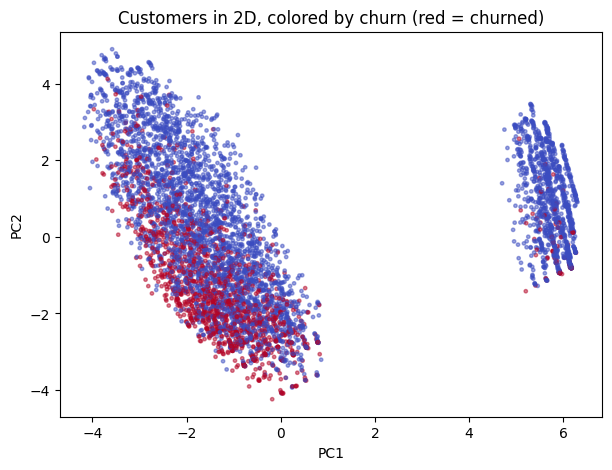

PC1 top loadings:
InternetService_No                      0.302
OnlineSecurity_No internet service      0.302
TechSupport_No internet service         0.302
StreamingTV_No internet service         0.302
DeviceProtection_No internet service    0.302
OnlineBackup_No internet service        0.302
dtype: float64


In [19]:
P = PCA(n_components=2).fit(Xs)
T = P.transform(Xs)
plt.figure(figsize=(7, 5))
plt.scatter(T[:, 0], T[:, 1], c=y_train, cmap='coolwarm', s=6, alpha=0.5)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Customers in 2D, colored by churn (red = churned)'); plt.show()
load = pd.Series(P.components_[0], index=X.columns)
print('PC1 top loadings:')
order = load.abs().sort_values(ascending=False).index
print(load.reindex(order).head(6).round(3))


### ** PCA Analysis & Feature Redundancy Response**

#### **1. Components Needed & Feature Redundancy**

* **Components Needed:** **15 out of 30 components** are required to explain **90%** of the total variance.


* **Feature Redundancy:** Reducing the dimensions by half (50% compression) without losing major information demonstrates **significant feature redundancy** in the dataset. Standard one-hot encoding created identical/duplicate indicator variables (such as `InternetService_No` and all related `"No internet service"` columns). This multi-collinearity causes severe instability and inflated coefficients in standard models like Logistic Regression unless regularized.


#### **2. Description of PC1 in Words**

* **PC1 Meaning:** Principal Component 1 captures **customers without internet service**.


* **Top Loadings Analysis:** PC1 is dominated by identical positive loadings (**0.302**) for `InternetService_No` alongside all non-internet feature flags (`OnlineSecurity_No internet service`, `TechSupport_No internet service`, `StreamingTV_No internet service`, `DeviceProtection_No internet service`, `OnlineBackup_No internet service`). High values on PC1 represent non-internet subscribers, completely separating them into the distinct cluster on the right side of the plot.


#### **3. 2D Scatter Plot & Class Separation**

* **Separation of Churners vs. Stayers:**
* **No internet group (Right cluster, PC1 > 4):** Contains almost exclusively blue points (stayers), showing an extremely low churn rate.


* **Internet group (Left cluster, PC1 < 1):** Churners (red) and stayers (blue) heavily overlap and intermingle throughout the main distribution.




* **Difficulty of Prediction Problem:**
* The linear projection in 2D shows that while isolating non-internet subscribers is trivial, **distinguishing churners from non-churners among active internet users is non-linear and challenging**.


* Linear boundaries alone are insufficient to separate the classes in reduced dimensions, justifying the need for flexible, high-capacity models like XGBoost to resolve the complex decision boundary.

### **Part 7: Choose by CV, Test Once, Save**

**Task 7.1: Final cross-validated comparison**


In [20]:
candidates = {
 'LR (tuned C)': lr.set_params(model__C=Cs[va.mean(axis=1).argmax()]),
 'RF (random search)': rs.best_estimator_,
 'XGBoost (tuned)': xs.best_estimator_,
}
rows = []
for name, m in candidates.items():
 cvs = cross_validate(m, X_train, y_train, cv=cv, scoring='roc_auc')
 rows.append({'model': name,
 'cv_auc': cvs['test_score'].mean(),
 'cv_std': cvs['test_score'].std()})
cmp = pd.DataFrame(rows)
print(cmp.round(4).to_string(index=False))

             model  cv_auc  cv_std
      LR (tuned C)  0.8464  0.0129
RF (random search)  0.8464  0.0114
   XGBoost (tuned)  0.8504  0.0125


**Task 7.2: Unlock the test set, exactly once**


In [21]:
best_name = cmp.loc[cmp['cv_auc'].idxmax(), 'model'] # chosen by CV only
best = candidates[best_name].fit(X_train, y_train)
prob = best.predict_proba(X_test)[:, 1]
pred = (prob >= 0.5).astype(int)
print(f'{best_name} on the test set (used once):')
print(f'AUC {roc_auc_score(y_test, prob):.4f} '
 f'recall {recall_score(y_test, pred):.3f} '
 f'precision {precision_score(y_test, pred):.3f}')
joblib.dump(best, 'churn_model.joblib') # you will deploy this in Week 4

XGBoost (tuned) on the test set (used once):
AUC 0.8478 recall 0.529 precision 0.662


['churn_model.joblib']

###  Final Model Selection & Test Set Analysis**

#### **1. Model Chosen and Justification**

* **Chosen Model:** **`XGBoost (tuned)`**

* **Justification:** From the cross-validation table, XGBoost achieved the highest mean cross-validated AUC score of **`0.8504`** (compared to `0.8464` for both Logistic Regression and Random Forest). Selection was strictly based on validation performance prior to evaluating the test set.


#### **2. Test Set AUC vs. Cross-Validation Range**

* **Single Test AUC:** **`0.8478`**

* **CV Mean & Standard Deviation:** $\text{Mean} = 0.8504$, $\text{Std} = 0.0125$

* **2 Std Interval:** $[0.8504 - 2(0.0125), 0.8504 + 2(0.0125)] \implies \mathbf{[0.8254, 0.8754]}$
* **Comparison:** Yes, the test AUC of **`0.8478`** lies well inside the $\text{mean} \pm 2\text{ std}$ confidence interval. This small drop of $0.0026$ from the CV mean demonstrates that the tuned model generalizes reliably without significant overfitting.


#### **3. Comparison with Week 2 Baseline & Tuning Impact**

* **Week 2 Baseline AUC:** $\approx 0.8460$ (Logistic Regression baseline)


* **Final Test AUC Gain:** Modest performance gain ($\approx \mathbf{0.0018\text{ to }0.0044}$).


* **Explanation:**
* The gain from hyperparameter tuning and model boosting was relatively small.


* In structured tabular datasets like customer churn, standard linear models with proper scaling and regularization already capture a large portion of the predictive signal.


* While complex tree-based ensembles (XGBoost) provide marginal gains in ROC-AUC, their main advantage lies in capturing non-linear feature interactions without extensive manual feature engineering.

### Check Your Understanding

#### 1. Model A vs. Model B Accuracy Comparison
* **Working:** The difference in accuracy is $\Delta p = 0.812 - 0.803 = 0.009$. The standard error of the accuracy difference for sample size $n = 1409$ is approximately $\text{SE} = \sqrt{\frac{p(1-p)}{n}} \approx \sqrt{\frac{0.81 \times 0.19}{1409}} \approx 0.0104$.
* **Answer:** Not necessarily. Since the difference between the two models ($0.009$) is smaller than $1 \times \text{SE}$ ($0.0104$), the performance gap is within normal statistical noise and not statistically significant on a test set of this size.



#### 2. StandardScaler Inside Pipeline During Cross-Validation
* Placing the `StandardScaler` inside the `Pipeline` ensures that feature mean and variance are computed using **only the training folds** for each split. If scaled beforehand on the whole dataset, information from the validation fold leaks into the training step, leading to data leakage and overly optimistic performance estimates.



#### 3. Total Model Fits Calculation
* **Working:** Total hyperparameter combinations $= 5 \times 4 \times 3 = 60$. Total fits $= 60 \text{ combinations} \times 5 \text{ folds}$.
* **Answer:** That requires **300 total model fits**.



#### 4. Why `gs.best_score_` is Optimistic
* `gs.best_score_` represents the maximum score chosen across many tested hyperparameter configurations on the validation folds. Because it selects the winner out of many trials, it suffers from optimization bias (winner's curse) and overfits slightly to the validation splits.



#### 5. Gradient Boosting and Gradient Descent
* In gradient boosting, each new tree attempts to predict the **residuals (pseudo-residuals)**, which are the negative gradients of the loss function with respect to the previous ensemble's predictions. This directly mirrors gradient descent in function space, where each step (tree) moves the predictions in the direction that minimizes total loss.



#### 6. K-means Clustering on Unscaled Features
* K-means relies on Euclidean distance to form clusters. Since `TotalCharges` has a much larger numerical range (e.g., thousands of dollars) compared to standard or binary features (e.g., 0 to 1), its distance calculations completely dominate the loss metric, causing K-means to group points almost exclusively by `TotalCharges`.